In [ ]:
import pandas as pd
import missingno as msno

df = pd.read_csv("https://www.dropbox.com/s/4y9ox46lqe8s2eq/NFL%20Play%20Data.csv?dl=1")

df.info(verbose=True)

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (25,51) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407688 entries, 0 to 407687
Data columns (total 102 columns):
 #    Column                       Dtype  
---   ------                       -----  
 0    Date                         object 
 1    GameID                       int64  
 2    Drive                        int64  
 3    qtr                          int64  
 4    down                         float64
 5    time                         object 
 6    TimeUnder                    int64  
 7    TimeSecs                     float64
 8    PlayTimeDiff                 float64
 9    SideofField                  object 
 10   yrdln                        float64
 11   yrdline100                   float64
 12   ydstogo                      int64  
 13   ydsnet                       int64  
 14   GoalToGo                     float64
 15   FirstDown                    float64
 16   posteam                      object 
 17   DefensiveTeam                object 
 18   desc                  

In [ ]:
df[["DefensiveTeam"]].replace("STL", "LA", regex=True)
df[["posteam"]].replace("STL", "LA", regex=True)
df[["DefensiveTeam"]].replace("JAC", "JAX", regex=True)
df[["posteam"]].replace("JAC", "JAX", regex=True)
df[["DefensiveTeam"]].replace("SD", "LAC", regex=True)
df[["posteam"]].replace("SD", "LAC", regex=True)

,posteam
0,PIT
1,PIT
2,PIT
3,PIT
4,PIT
...,...
407683,NaN
407684,BAL
407685,BAL
407686,CIN


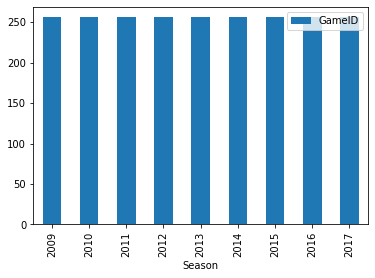

In [ ]:
#Question 1
#Answer: 256

dfS = df.groupby(['Season'])
dfBC = dfS[["GameID"]].nunique()
dfBC.plot.bar()

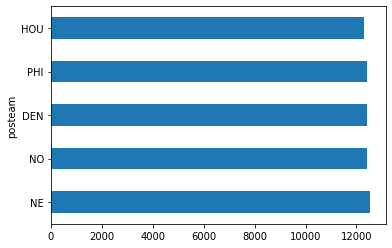

In [ ]:
#Question 2
#Answer:
#1. NE: 12520
#2. NO: 12408
#3. DEN: 12398
#4. PHI: 12397
#5. HOU: 12315

dfT = df.groupby(['posteam']).count()
dfHBCT = dfT["Touchdown"].nlargest(5)
dfHBCT.plot.barh()

In [ ]:
#Question 3
#Answer:
#1. CLE    1439
#2. BAL    1417
#3. NO     1415
#4. MIN    1404
#5. JAC    1395
#6. MIA    1385
#7. NE     1377
#8. TEN    1374
#9. TB     1362
#10. DEN    1359

dfS = df.loc[df["Season"] == 2012]
dfT = dfS.groupby(['DefensiveTeam']).count()
dfHBCD = dfT["Touchdown"].nlargest(10)
dfHBCD
#dfHBCD.plot.barh()

DefensiveTeam
CLE    1439
BAL    1417
NO     1415
MIN    1404
JAC    1395
MIA    1385
NE     1377
TEN    1374
TB     1362
DEN    1359
Name: Touchdown, dtype: int64

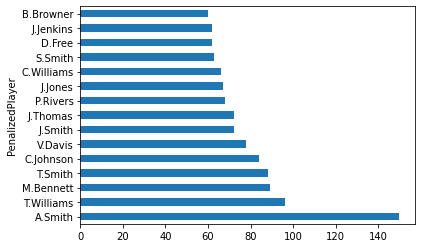

In [ ]:
#Question 4 (Part 1)
#Answer:
#Number of Penalties
# 1. A.Smith: 150
# 2. T.Williams: 96
# 3. M.Bennett: 89
# 4. T.Smith: 88
# 5. C.Johnson: 84
# 6. V.Davis: 78
# 7. J.Smith: 72
# 8. J.Thomas: 72
# 9. P.Rivers: 68
# 10. J.Jones: 67
# 11. C.Williams: 66
# 12. S.Smith: 63
# 13. D.Free: 62
# 14. J.Jenkins: 62
# 15. B.Browner: 60

dfPT = df.groupby(['PenalizedPlayer']).count()
dfBCPT = dfPT['Penalty.Yards'].nlargest(15)
dfBCPT.plot.barh()

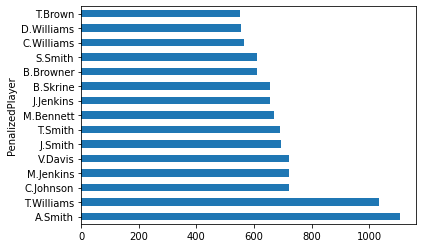

In [ ]:
#Question 4 (Part 2)
#Answer:
#Penalty Yards
# 1. A.Smith: 1108.0
# 2. T.Williams: 1035.0
# 3. C.Johnson: 723.0
# 4. M.Jenkins: 722.0
# 5. V.Davis: 720.0
# 6. J.Smith: 693.0
# 7. T.Smith: 692.0
# 8. M.Bennett: 671.0
# 9. J.Jenkins: 656.0
# 10. B.Skrine: 655.0
# 11. B.Browner: 611.0
# 12. S.Smith: 609.0
# 13. C.Williams: 565.0
# 14. D.Williams: 555.0
# 15. T.Brown: 550.0

dfPY = df.groupby(['PenalizedPlayer']).agg('sum')
dfBCPY = dfPY['Penalty.Yards'].nlargest(15)
dfBCPY.plot.barh()

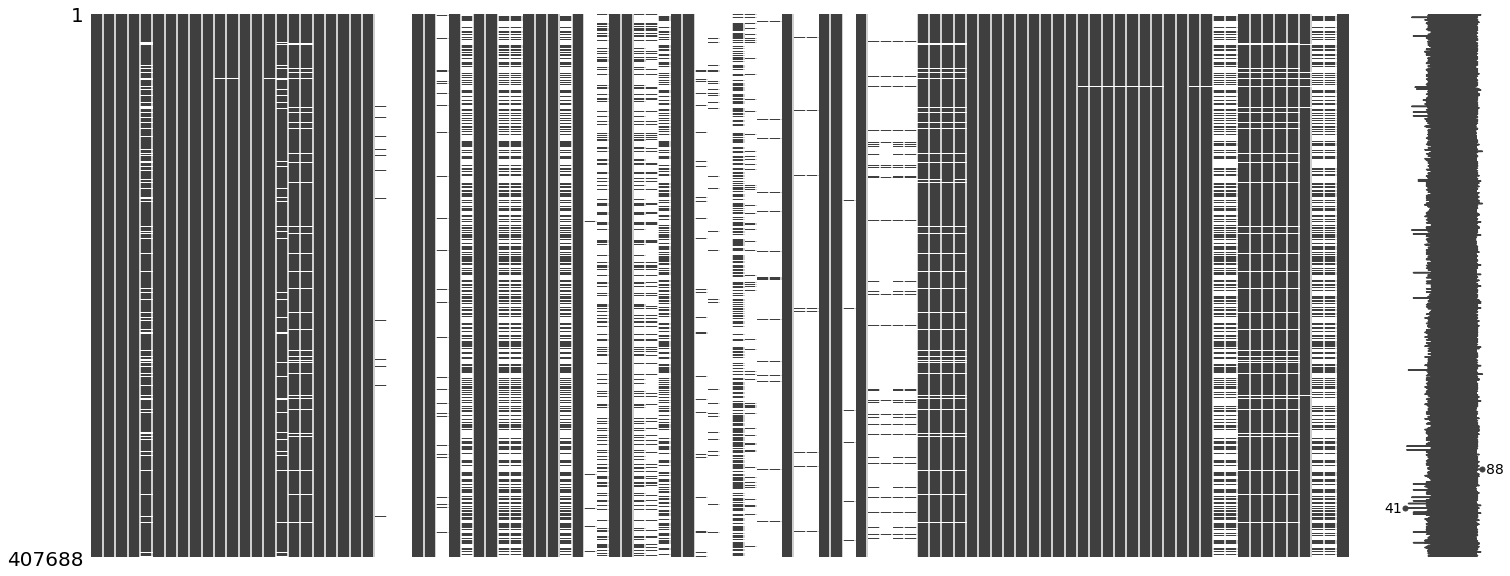

In [ ]:
#Question 5
#Answer: That...

msno.matrix(df)

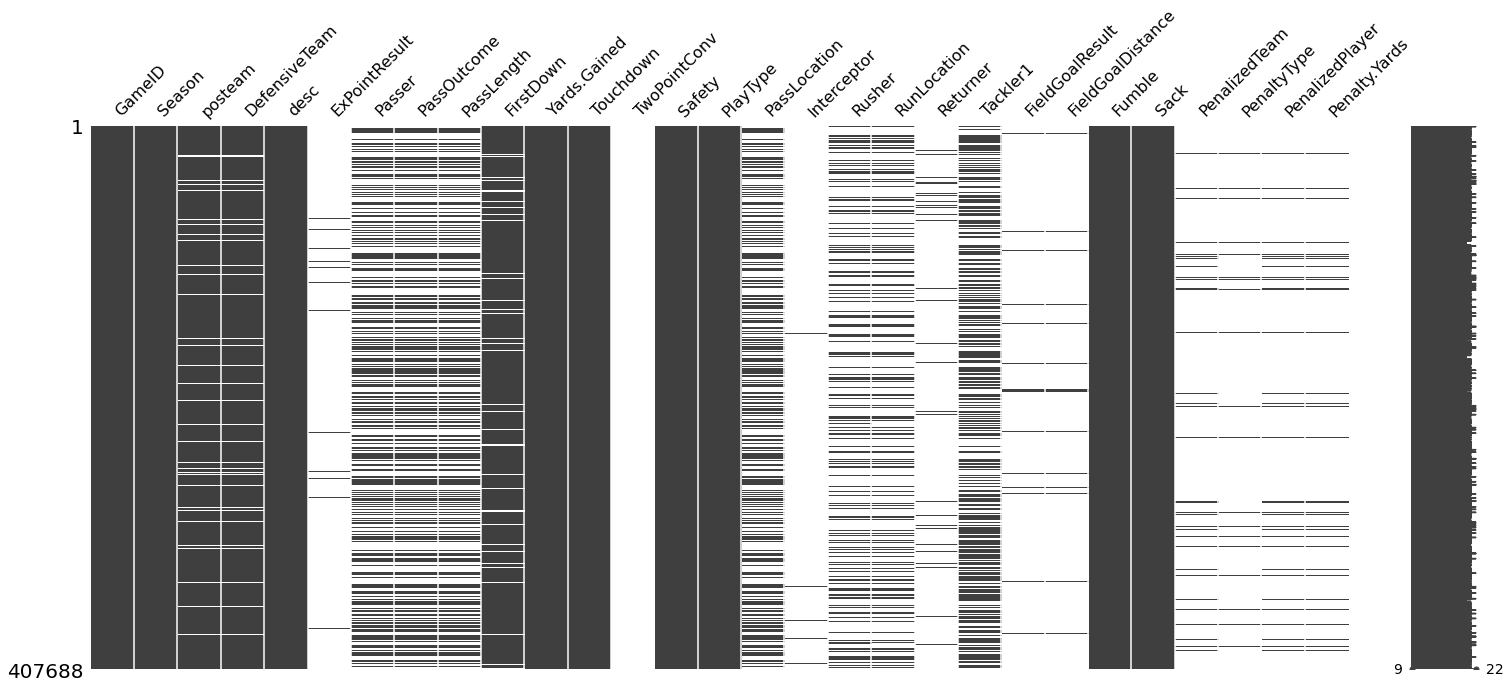

In [ ]:
#Question 6
#Answer: That!

dfN = df[['GameID', 'Season', 'posteam', 'DefensiveTeam', 'desc', 'ExPointResult', 'Passer', 'PassOutcome', 'PassLength', 'FirstDown', 'Yards.Gained', 'Touchdown', 'TwoPointConv', 'Safety', 'PlayType', 'PassLocation', 'Interceptor', 'Rusher', 'RunLocation', 'Returner', 'Tackler1', 'FieldGoalResult', 'FieldGoalDistance', 'Fumble', 'Sack', 'PenalizedTeam', 'PenaltyType', 'PenalizedPlayer', 'Penalty.Yards']]
msno.matrix(dfN)

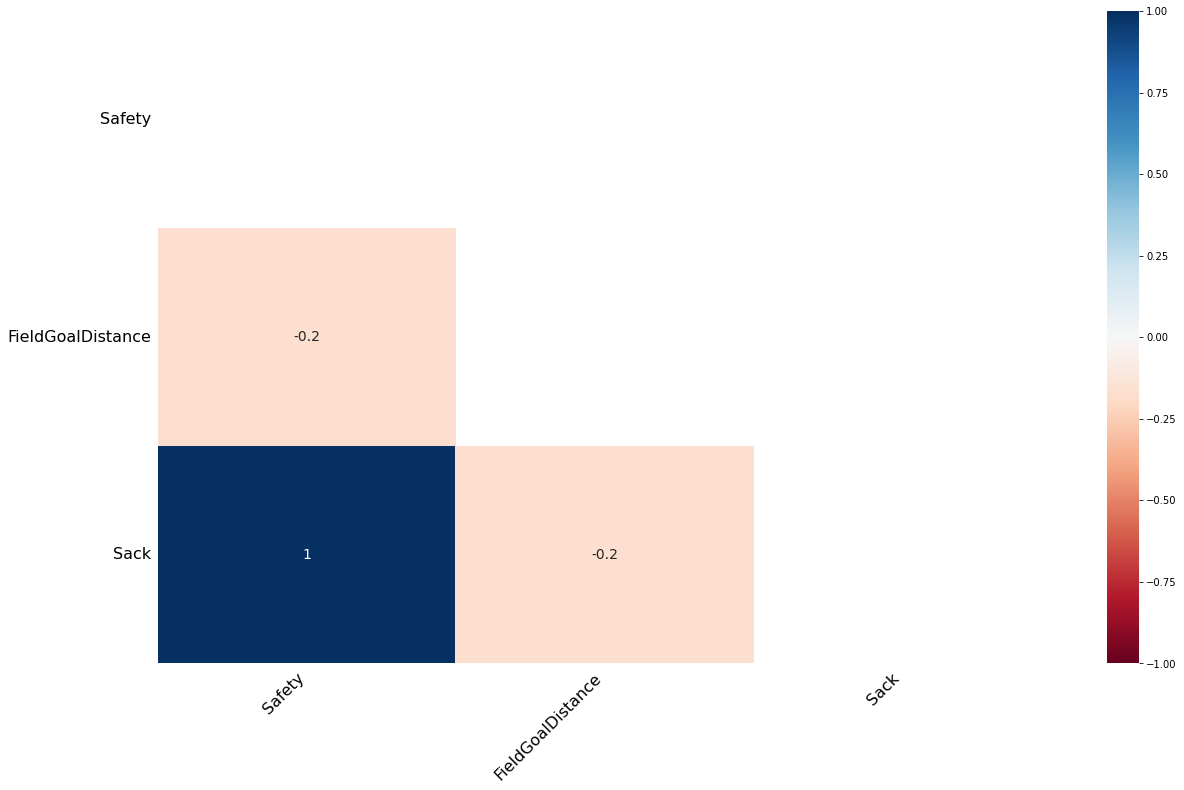

In [ ]:
#Question 7
#Answer:

dfHM = dfN.corr()
msno.heatmap(dfHM)

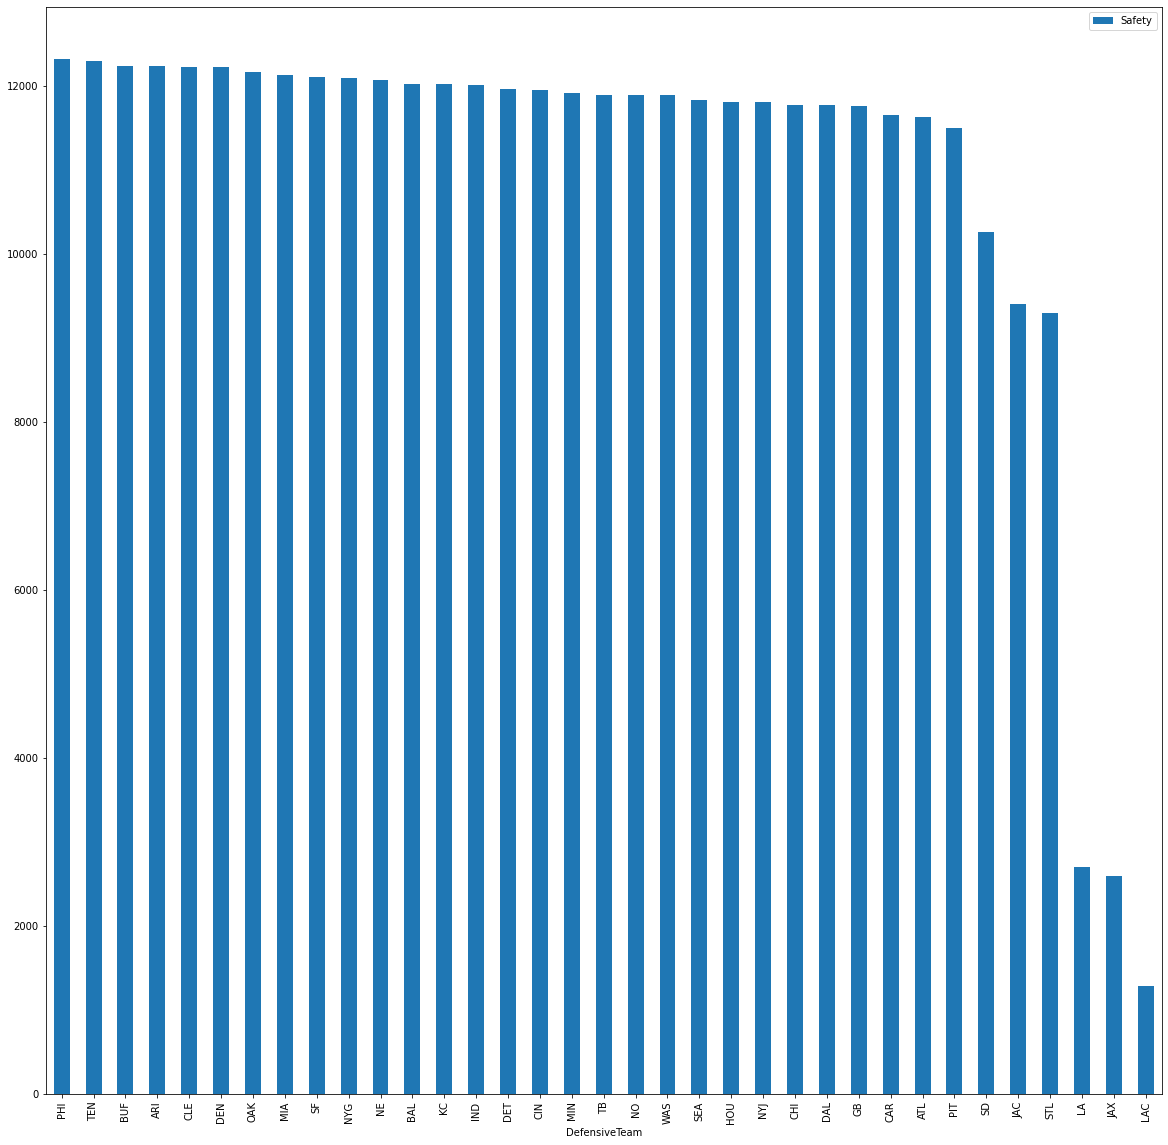

In [ ]:
#Question 8
#Answer:

dfS = df.groupby(['DefensiveTeam']).count()
dfBCS = dfS[["Safety"]]
dfBCSF = dfBCS.sort_values("Safety", ascending=False)
dfBCSF.plot.bar(figsize=(20,20))

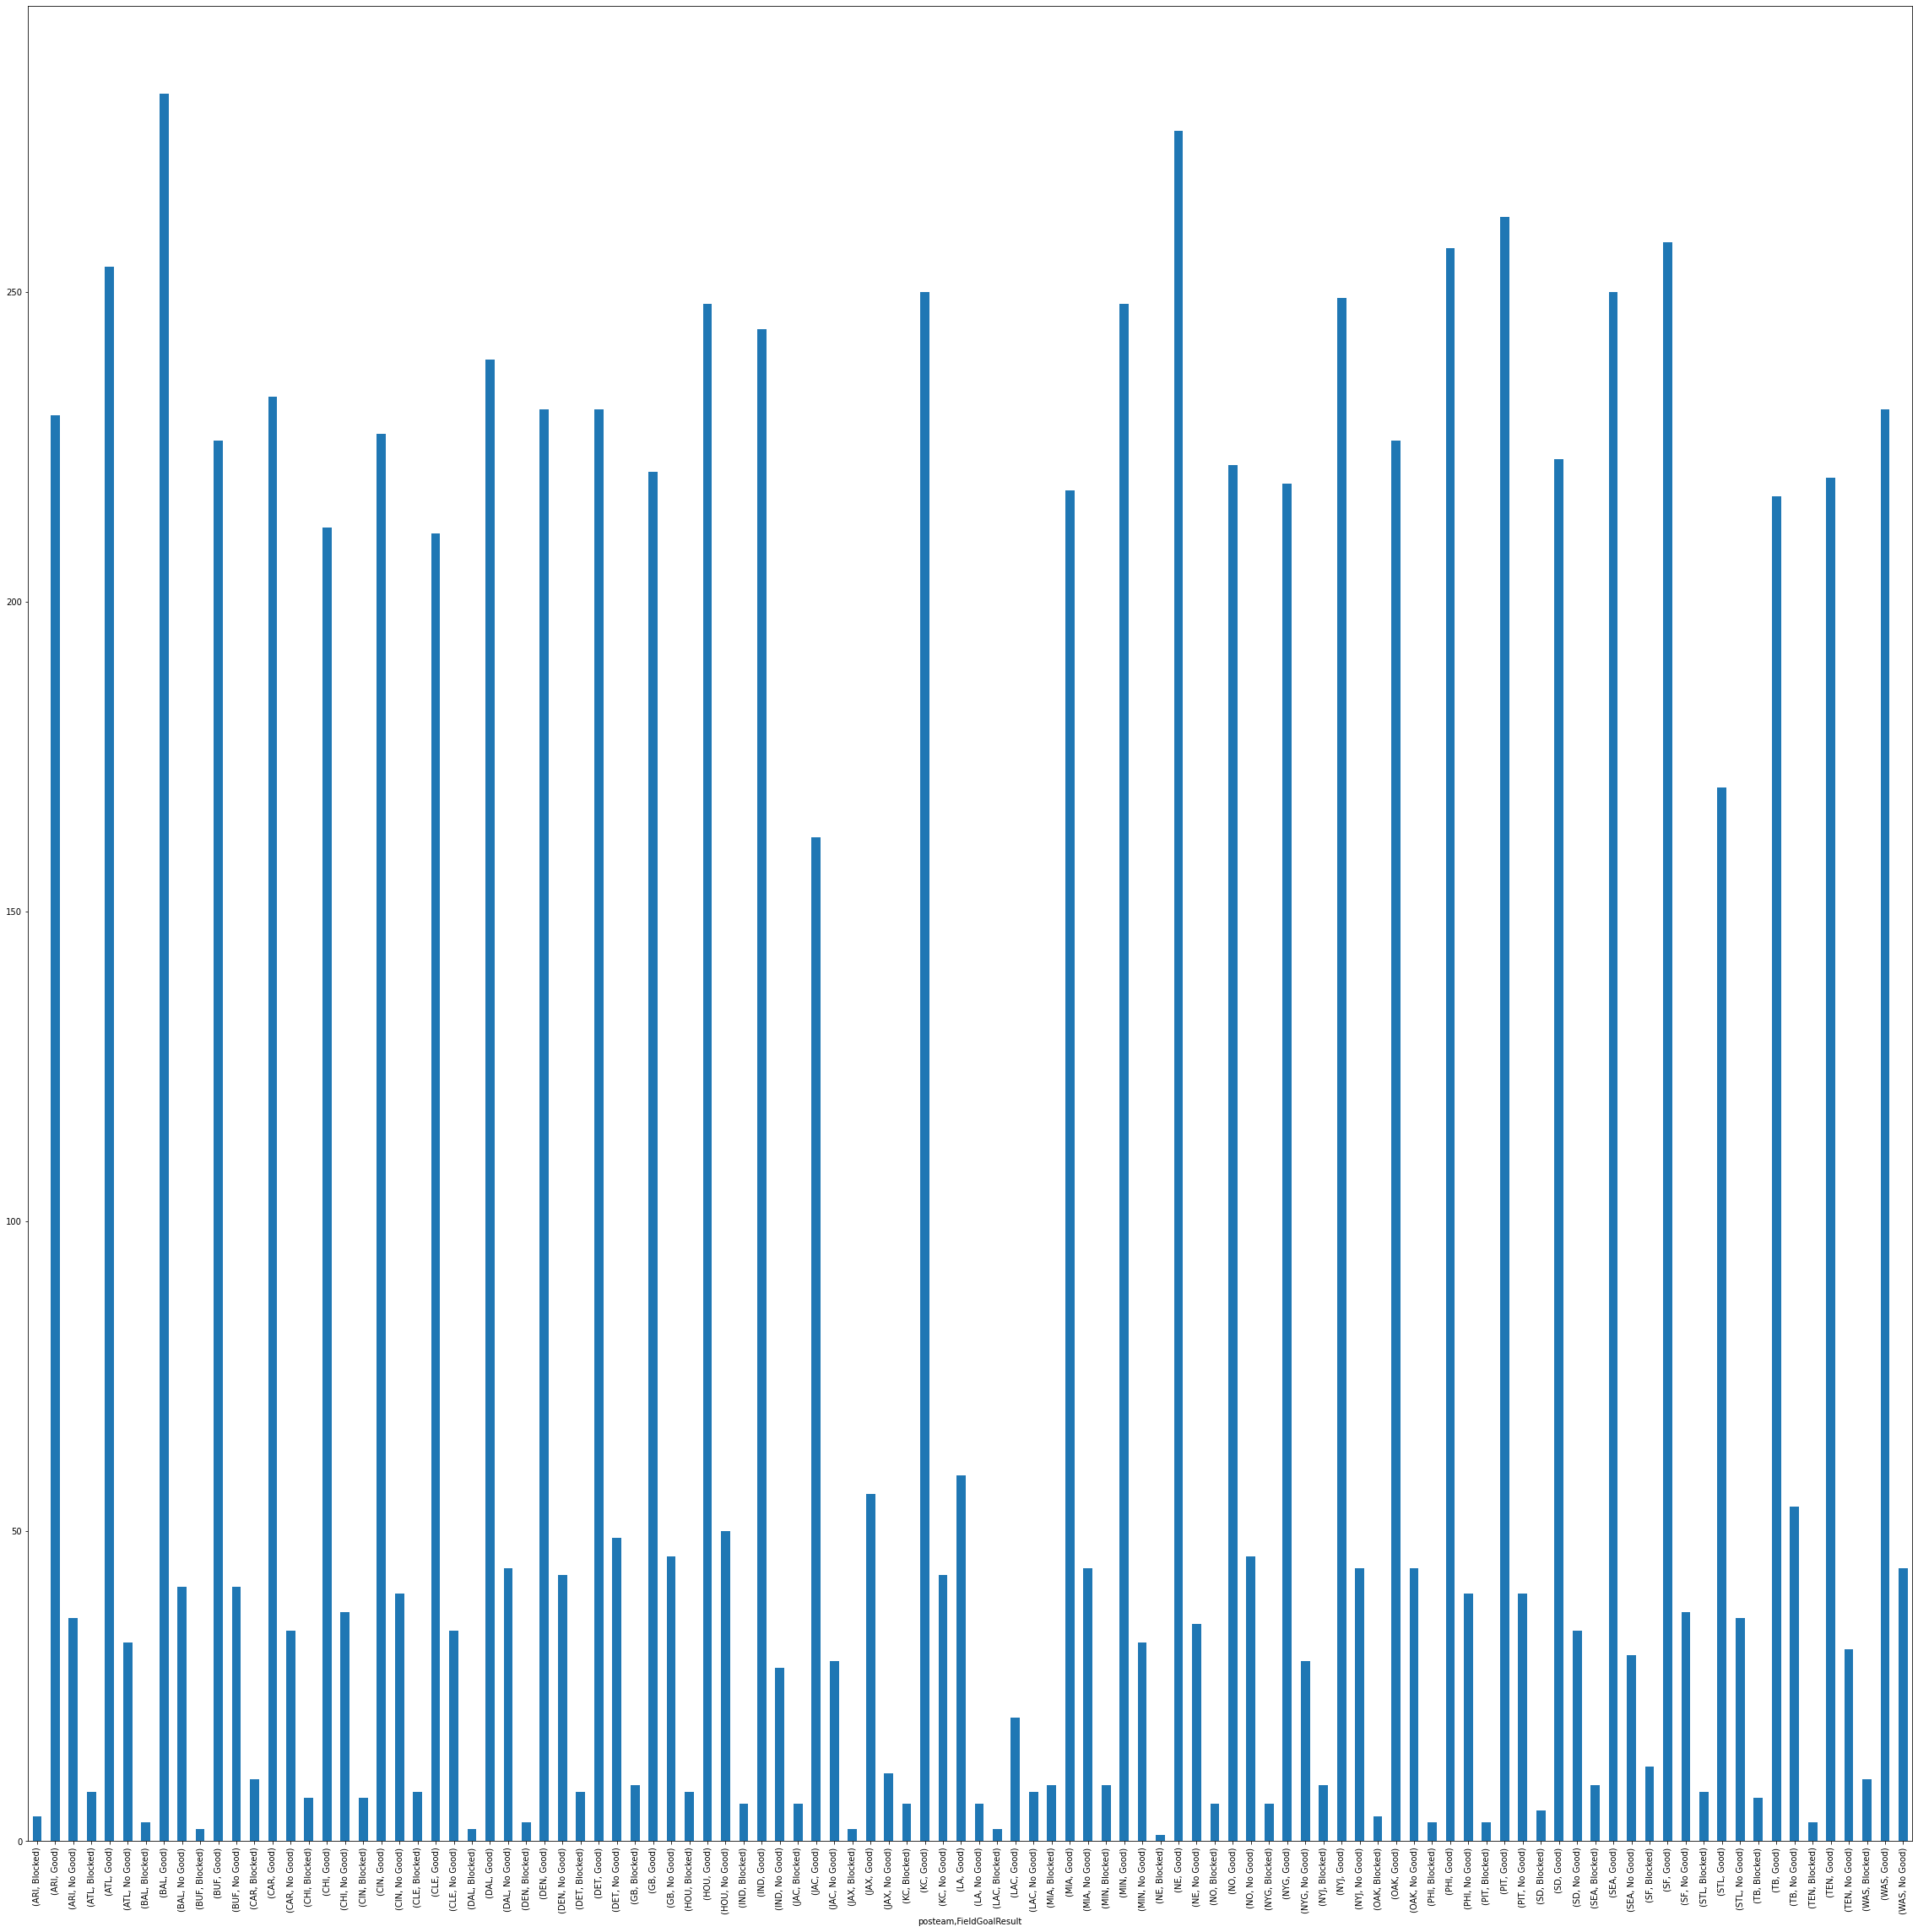

In [ ]:
#Question 9
#Answer:

dfK = dfN[['FieldGoalResult', 'posteam']].dropna()
dfK
dfT = dfK.groupby(['posteam', 'FieldGoalResult'])['FieldGoalResult'].count()
dfT
dfT.plot.bar(stacked=True, figsize=(40,40))

In [ ]:
#Question 10
#Answer: ¯\_(ツ)_/¯

dfN[['desc']]

,desc
0,R.Bironas kicks 67 yards from TEN 30 to PIT 3....
1,(14:53) B.Roethlisberger pass short left to H....
2,(14:16) W.Parker right end to PIT 44 for -3 ya...
3,(13:35) (Shotgun) B.Roethlisberger pass incomp...
4,(13:27) (Punt formation) D.Sepulveda punts 54 ...
...,...
407683,Timeout #1 by BAL at 00:28.
407684,(:28) (Shotgun) J.Flacco pass incomplete short...
407685,(:24) (Shotgun) J.Flacco pass short middle to ...
407686,(:14) A.Dalton kneels to BAL 37 for -1 yards.
